In [1]:
!pip install langchain langchain_openai langsmith pandas langchain_experimental matplotlib langgraph langchain_core duckduckgo-search langchain-community chromadb

  Using cached langchain-0.1.20-py3-none-any.whl.metadata (13 kB)
INFO: pip is looking at multiple versions of langchain-experimental to determine which version is compatible with other requirements. This could take a while.
  Using cached langchain_experimental-0.4.1-py3-none-any.whl.metadata (1.3 kB)
Using cached langchain_experimental-0.4.1-py3-none-any.whl (210 kB)
  Attempting uninstall: langchain_experimental
    Found existing installation: langchain-experimental 0.0.50
    Uninstalling langchain-experimental-0.0.50:
      Successfully uninstalled langchain-experimental-0.0.50


In [2]:
import os
from uuid import uuid4

In [3]:
unique_id = uuid4().hex[0:8]
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHIN_PROJECT'] = f'Define Custom Tools - {unique_id}'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY'] = ''
os.environ['OPENAI_API_KEY'] = ''

In [4]:
unique_id

'8a1bf545'

커스텀 툴에 적절한 이름, 설명, JSON스키마가 제공되면 모델의 성능이 향상 됨

Creating tools from functions

In [5]:
from langchain_core.tools import tool

In [6]:
@tool
def multiply(a:int, b:int) -> int:
    """Multiply two numbers."""
    return a*b

In [7]:
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiply two numbers.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [8]:
from typing import Annotated, List

In [9]:
@tool
def multiply_by_max(
    a: Annotated[int, "scale factor"],
    b: Annotated[List[int], "list of ints over which to take maximum"],
) -> int:
    """Multiply a by the maximum of b."""
    return a * max(b)

print(multiply_by_max.args_schema.model_json_schema())

{'description': 'Multiply a by the maximum of b.', 'properties': {'a': {'description': 'scale factor', 'title': 'A', 'type': 'integer'}, 'b': {'description': 'list of ints over which to take maximum', 'items': {'type': 'integer'}, 'title': 'B', 'type': 'array'}}, 'required': ['a', 'b'], 'title': 'multiply_by_max', 'type': 'object'}


In [10]:
@tool(parse_docstring=True)
def foo(bar: str, baz: int) -> str:
    """The foo.

    Args:
        bar: The bar.
        baz: The baz.
    """
    return bar


print(foo.args_schema.model_json_schema())

{'description': 'The foo.', 'properties': {'bar': {'description': 'The bar.', 'title': 'Bar', 'type': 'string'}, 'baz': {'description': 'The baz.', 'title': 'Baz', 'type': 'integer'}}, 'required': ['bar', 'baz'], 'title': 'foo', 'type': 'object'}


LLM과 정의한 Custom Tool 연동

In [30]:
tool = multiply
tools = [tool]

In [12]:
from langchain_openai import ChatOpenAI

In [24]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph , START, END
from langgraph.graph.message import add_messages

In [26]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

llm = ChatOpenAI(
    model = 'gpt-4o-mini',
    temperature=0,
)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

graph_builder.add_node('chatbot', chatbot)

In [27]:
import json
from langchain_core.messages import ToolMessage

In [31]:
class BasicToolNode:
    def __init__(self, tools:list) ->None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get('messages', []):
            message = messages[-1]
        else:
            raise ValueError('No message found in input')
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args'])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name = tool_call['name'],
                    tool_call_id = tool_call['id'],
                )
            )
        return {'messages': outputs}
    
tool_node = BasicToolNode(tools = [tool])
graph_builder.add_node('tools', tool_node)

In [34]:
from typing import Literal

In [35]:
def route_tools(
        state: State,
) -> Literal['tools', '__end__']:
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get('messages', []):
        ai_message = messages[-1]
    else:
        raise ValueError(f'No messages found in input state to tool_edge: {state}')
    if hasattr(ai_message, 'tool_calls') and len(ai_message.tool_calls) > 0:
        return 'tools'
    return '__end__'

graph_builder.add_conditional_edges(
    'chatbot',
    route_tools,
    {'tools': 'tools', '__end__':'__end__'},
)

graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START, 'chatbot')
graph = graph_builder.compile()

In [36]:
from IPython.display import Image, display

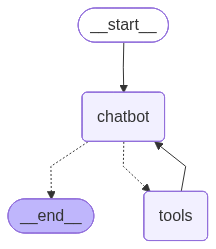

In [37]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [38]:
from langchain_core.messages import BaseMessage

In [43]:
result = graph.invoke({'messages': [{'role': 'user', 'content': '6*7을 계산해줘'}]})
print( result['messages'][-1].content)

6 * 7의 결과는 42입니다.


In [42]:
result = graph.invoke({'messages': [{'role': 'user', 'content': '황제 펭귄에 대해 알려줘'}]})
print( result['messages'][-1].content)

황제 펭귄(Emperor Penguin)은 세계에서 가장 큰 펭귄 종으로, 남극 대륙에서 주로 서식합니다. 이들은 독특한 생태적 특성과 행동으로 잘 알려져 있습니다. 다음은 황제 펭귄에 대한 몇 가지 주요 정보입니다:

1. **크기**: 성체 황제 펭귄은 약 1.2미터에서 1.3미터 정도 자라며, 체중은 22kg에서 45kg까지 다양합니다.

2. **서식지**: 황제 펭귄은 남극의 얼음과 눈이 많은 지역에서 살며, 극한의 추위에서도 생존할 수 있는 능력을 가지고 있습니다.

3. **번식**: 황제 펭귄은 독특한 번식 방식을 가지고 있습니다. 암컷은 한 개의 알을 낳고, 수컷이 알을 품는 동안 암컷은 먹이를 찾으러 나갑니다. 수컷은 알을 발바닥에 두고 따뜻하게 유지하며, 이 과정에서 약 2개월 동안 먹지 않고 지냅니다.

4. **사회적 행동**: 황제 펭귄은 강한 사회적 유대감을 형성하며, 대규모 집단을 이루어 생활합니다. 이들은 서로의 체온을 유지하기 위해 밀집하여 서 있는 행동을 보입니다.

5. **식습관**: 주로 물고기, 오징어, 크릴 등을 먹으며, 수중에서 뛰어난 수영 능력을 발휘합니다.

황제 펭귄은 그들의 독특한 생태와 행동으로 인해 많은 연구의 대상이 되고 있으며, 기후 변화와 같은 환경적 요인에 민감한 종으로 알려져 있습니다.
